# Data import
Just about reading the CSV and looking at basic facts

In [19]:
from pathlib import Path 
import pandas as pd 

measurements = pd.read_csv(Path("output.1.csv"))
measurements.head()

,id,origin,ground_truth,guess,ip_v4,ip_v6,latency,hops,count,date_time
0,1004021,NordVPN,PL,NaN,193.42.98.247,NaN,3.600000e-07,5.0,4,2026-03-25 11:31:58.477648
1,995081,NordVPN,NO,NaN,45.84.39.120,NaN,2.400000e-07,6.0,4,2026-03-25 11:31:58.628444
2,464,Mullvad,us,NaN,146.70.187.66,2a0d:5600:6:105::f001,4.200000e-07,4.0,4,2026-03-25 11:31:58.696200
3,1007793,NordVPN,AL,NaN,217.216.60.1,NaN,1.800000e-07,6.0,4,2026-03-25 11:31:58.742468
4,1007927,NordVPN,BR,NaN,138.199.58.176,NaN,3.600000e-07,8.0,4,2026-03-25 11:31:58.947453


Here we can notice most of our servers are located in the US. The guess column serves no purpose, and neither does the ip_v6. 
I'm however surprised to see no nulls in the hops and latency attributes. 

In [25]:
measurements.info()
measurements.ground_truth.value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 9716 entries, 0 to 9715
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            9716 non-null   int64  
 1   origin        9716 non-null   str    
 2   ground_truth  9716 non-null   str    
 3   ip_v4         9716 non-null   str    
 4   latency       9716 non-null   float64
 5   hops          9716 non-null   float64
 6   count         9716 non-null   int64  
 7   date_time     9716 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 607.4 KB


ground_truth
US    3352
GB    1134
CA     512
DE     439
FR     422
      ... 
ng       2
LA       2
PG       2
UZ       2
BT       2
Name: count, Length: 180, dtype: int64

The spread is not that impressive, but when it comes to hops, it appears it is skewed towards the left. 

In [21]:
import matplotlib.pyplot as plt 

measurements.drop(columns=["guess", "ip_v6"], inplace=True)
measurements.describe()

,id,latency,hops,count
count,9.716000e+03,9.716000e+03,9716.000000,9716.0
mean,9.344509e+05,3.281093e-07,5.681762,4.0
std,2.324001e+05,6.108527e-07,2.627226,0.0
min,0.000000e+00,0.000000e+00,0.000000,4.0
25%,9.762462e+05,2.400000e-07,4.000000,4.0
50%,9.950465e+05,3.000000e-07,5.000000,4.0
75%,1.005302e+06,3.600000e-07,7.000000,4.0
max,1.008380e+06,5.186000e-05,20.000000,4.0


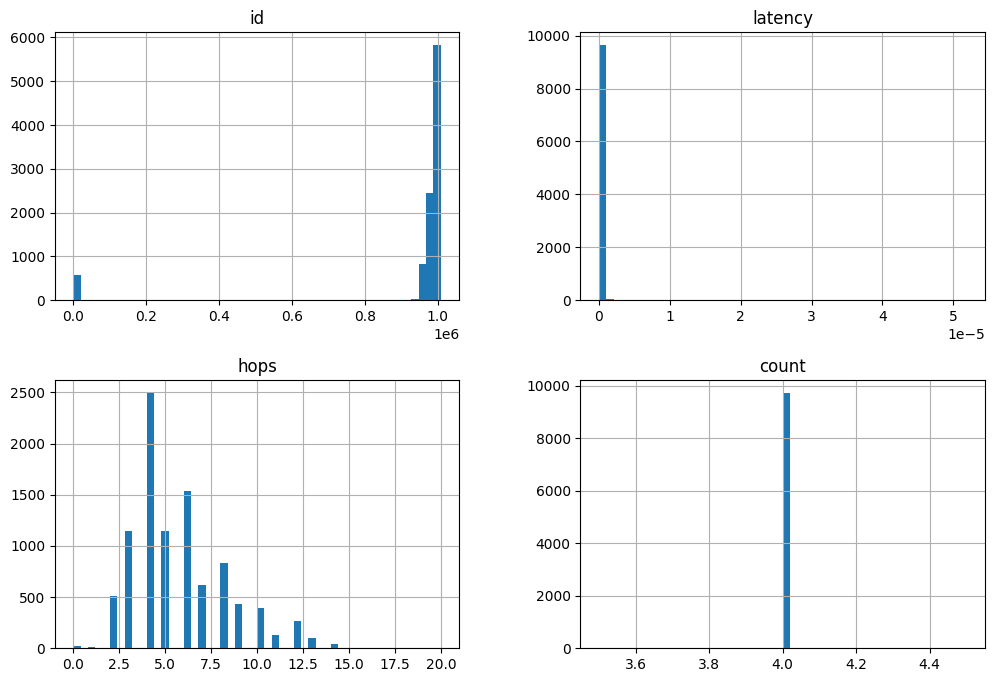

In [23]:

measurements.hist(bins=50, figsize=(12, 8))
plt.show()

The dataset will be split into a training set, a dev set, and a test set, per Geron's own recommendations; thus holdout validation is our chosen validation technique, for now. The training set and dev set will come from our RIPE anchors. The final test set will come from our VPNs. We will go for stratified sampling on as to make sure both splits are representative of our whole dataset. 


In [26]:
from sklearn.model_selection import train_test_split

grouped = measurements.groupby(measurements.origin)
traindev_set = grouped.get_group("RIPE") # Exclude the VPN measurements

# test size -> 0.2 means 20% 
train_set, dev_set = train_test_split(traindev_set, test_size=0.2, stratify=traindev_set["ground_truth"], random_state=1312)
train_set.describe()

KeyError: 'RIPE'